In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import plotly.graph_objs as go
from plotly.offline import iplot, init_notebook_mode
import seaborn as sns

from scipy.signal import savgol_filter
from sklearn.metrics import roc_curve, auc
init_notebook_mode(True)
%matplotlib inline

In [24]:
BASEPATH = Path('../results_timeseries_acc_nn_dropout40_batihan/1999/')

# Learning Curve

In [25]:
results = pd.read_csv(BASEPATH/'result.csv', index_col=0)

In [26]:
results.head()

,train_loss,test_loss,train_acc,test_acc
0,0.703930,0.641996,0.445673,0.557692
1,0.857985,0.636836,0.545673,0.557692
2,0.665586,0.632428,0.488942,0.557692
3,0.739448,0.635243,0.464423,0.557692
4,0.704952,0.636097,0.476442,0.557692


In [27]:
trace1 = go.Scatter(x=results.index, 
                    y=results['train_loss'],
                    name='training loss')
trace2 = go.Scatter(x=results.index, 
                    y=results['test_loss'],
                    name='test loss')
trace3 = go.Scatter(x=results.index, 
                    y=results['train_acc'],
                    name='training accuracy')
trace4 = go.Scatter(x=results.index, 
                    y=results['test_acc'],
                    name='test accuracy')

trace5 = go.Scatter(x=results.index, 
                    y=savgol_filter(results['test_acc'], 601, 3),
                    name='test accuracy curvefit',
                   line=dict(width=4))

trace6 = go.Scatter(x=results.index, 
                    y=savgol_filter(results['train_acc'], 601, 3),
                    name='train accuracy curvefit',
                   line=dict(width=4))


layout = go.Layout(title='Learning Curve',
                  xaxis={'title':'# of epochs'})
fig = go.Figure(data=[trace1, trace2, trace3, trace4, trace5, trace6],
               layout=layout)
iplot(fig)

# Confusion Matrix

In [28]:
cm_train = np.loadtxt(BASEPATH/"cm_train.txt")
cm_test = np.loadtxt(BASEPATH/"cm_test.txt")

[Text(33.0, 0.5, 'true label'), Text(0.5, 15.0, 'predicted label')]

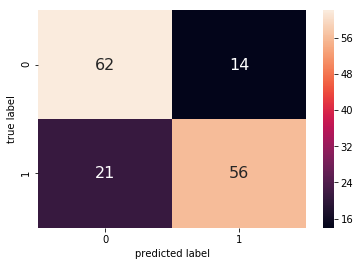

In [29]:
ax = sns.heatmap(cm_train, annot=True, annot_kws={"size": 16})
ax.set(xlabel='predicted label', ylabel='true label')

[Text(33.0, 0.5, 'true label'), Text(0.5, 15.0, 'predicted label')]

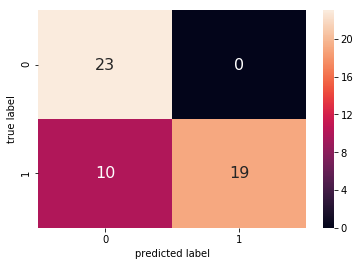

In [30]:
ax = sns.heatmap(cm_test, annot=True, annot_kws={"size": 16})
ax.set(xlabel='predicted label', ylabel='true label')

# ROC-AUC

In [31]:
train_pred = pd.read_csv(BASEPATH/'train_pred.csv', index_col=0)

In [32]:
train_pred.head()

,label,pred,proba0,proba1
0,0,0,0.939017,0.060983
1,0,0,0.989385,0.010615
2,0,0,0.952495,0.047505
3,0,0,0.522799,0.477201
4,1,1,0.015173,0.984827


In [33]:
fpr, tpr, thresholds = roc_curve(train_pred['label'], train_pred['proba1'])
auc_score = auc(fpr,tpr)

In [34]:
trace = go.Scatter(x=fpr, y=tpr, name=f'AUC: {auc_score:.2f}')
trace45 = go.Scatter(x=[0,1], y=[0,1], name='random guess', mode='lines', 
                     line=dict(dash='dash'))

layout = go.Layout(title='ROC-AUC',
                  xaxis={'title':'fpr'},
                  yaxis={'title':'tpr'},
                  font=dict(size=14))
fig = go.Figure(data=[trace, trace45],
               layout=layout)
iplot(fig)